In [1]:
pip install util-gfsilveira

In [2]:
#gerar gráfico
import matplotlib
#estruturação dos dados
import numpy as np
#gerar gráfico
import seaborn as sns
#gerar gráfico
import matplotlib.pyplot as plt
#Carregar o modelo
from keras.models import load_model
#salvar/carregar arquivos em diferentes formatos
import joblib

In [3]:
#Importando o modelo contendo os valores previstos para o número de células nas imagens
modelo_maior_erro = load_model('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/teste modelos/modelo_fluore_HBMEC_100_75_50_25_2025-11-13.keras')
modelo_maior_erro

<Sequential name=sequential, built=True>

In [4]:
X_test_maior_erro = joblib.load('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HBMEC/imagens_HBMEC_validação_10%_fluore_2025-11-13.gz') #carregando arquivo
X_test_maior_erro.shape

(24, 300, 300, 3)

In [5]:
y_test_maior_erro = joblib.load('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HBMEC/rótulos_HBMEC_validação_10%_fluore_2025-11-13.gz') #carregando arquivo
y_test_maior_erro.shape

(24,)

In [6]:
#ROTULOS SALVOS EM LISTA

lista_observado_maior_erro = list(y_test_maior_erro)
len(lista_observado_maior_erro)

24

In [7]:
#PREDIÇÃO SALVO EM LISTA

dados_prev = modelo_maior_erro.predict(X_test_maior_erro)
lista_previsto_maior_erro = dados_prev.flatten().tolist()
len(lista_previsto_maior_erro)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


24

In [8]:
lista_previsto_maior_erro

[0.19904610514640808,
 0.27651679515838623,
 0.15809684991836548,
 0.19235685467720032,
 0.30864059925079346,
 0.19492875039577484,
 0.1687013953924179,
 0.195794939994812,
 0.20892378687858582,
 0.10625206679105759,
 0.22121626138687134,
 0.16897660493850708,
 0.1834370493888855,
 0.16804243624210358,
 0.1523740291595459,
 0.3124706447124481,
 0.24666792154312134,
 0.2849290072917938,
 0.2520913779735565,
 0.2913324534893036,
 0.2647908627986908,
 0.1837303191423416,
 0.13793854415416718,
 0.16471464931964874]

In [9]:
import pandas as pd
from scipy.stats.stats import pearsonr as stats

/tmp/ipython-input-3864774765.py:2: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr as stats


In [10]:
#DATAFRAME - ORGANIZAÇÃO DAS LISTAS
#COLUNA 1 ROTULO/ COLUNA 2 PREDITO

df_maior_erro = pd.DataFrame(zip(lista_observado_maior_erro,lista_previsto_maior_erro),
                             columns = ['Observed values','Lista preditos'])
df_maior_erro.head()

,Observed values,Lista preditos
0,0.127821,0.199046
1,0.307947,0.276517
2,0.229978,0.158097
3,0.138553,0.192357
4,0.231501,0.308641


In [11]:
#ARREDONDANDO O PREDITO ('lista preditos')

teste = round(df_maior_erro['Lista preditos'],2)
df_maior_erro['Predicted values'] = teste
df_maior_erro.head()

,Observed values,Lista preditos,Predicted values
0,0.127821,0.199046,0.20
1,0.307947,0.276517,0.28
2,0.229978,0.158097,0.16
3,0.138553,0.192357,0.19
4,0.231501,0.308641,0.31


In [12]:
#REORGANIZANDO AS COLUNAS

df_maior_erro = df_maior_erro.reindex(columns=['Observed values','Predicted values','Lista preditos'])
df_maior_erro.head()

,Observed values,Predicted values,Lista preditos
0,0.127821,0.20,0.199046
1,0.307947,0.28,0.276517
2,0.229978,0.16,0.158097
3,0.138553,0.19,0.192357
4,0.231501,0.31,0.308641


In [13]:
#BIBLIOTECA CORRELAÇÃO
from scipy.stats.stats import spearmanr as spearman #importando a biblioteca para gráfico de correlação

/tmp/ipython-input-923420305.py:2: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import spearmanr as spearman #importando a biblioteca para gráfico de correlação


In [14]:
# #CALCULO DE CORRELAÇÃO

col1_obt = 0 #Observed value
col2_prev = 1 #Predicted values
pear_pos_maior_erro = stats(df_maior_erro[df_maior_erro.columns[col1_obt]],
                            df_maior_erro[df_maior_erro.columns[col2_prev]])

AttributeError: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'

In [15]:
from scipy import stats

# Verifique se as colunas contêm apenas valores numéricos
df_maior_erro[df_maior_erro.columns[col1_obt]] = pd.to_numeric(df_maior_erro[df_maior_erro.columns[col1_obt]], errors='coerce')
df_maior_erro[df_maior_erro.columns[col2_prev]] = pd.to_numeric(df_maior_erro[df_maior_erro.columns[col2_prev]], errors='coerce')

# Remova as linhas com valores NaN resultantes da conversão
df_maior_erro = df_maior_erro.dropna(subset=[df_maior_erro.columns[col1_obt], df_maior_erro.columns[col2_prev]])

# Calcular a correlação
pear_pos_maior_erro = stats.pearsonr(df_maior_erro[df_maior_erro.columns[col1_obt]],
                                     df_maior_erro[df_maior_erro.columns[col2_prev]])

print(pear_pos_maior_erro)

PearsonRResult(statistic=np.float64(0.24242199486366892), pvalue=np.float64(0.253725189950419))


<Figure size 1500x1500 with 0 Axes>

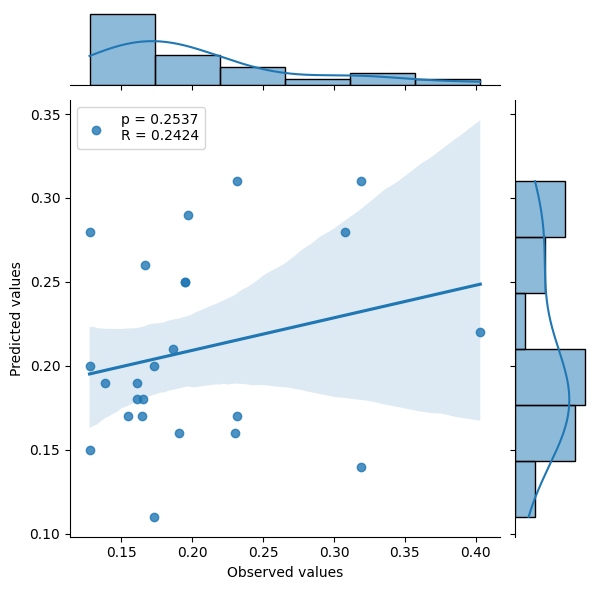

In [16]:
plt.figure(figsize=(15,15))
sns.jointplot(
    x=df_maior_erro.columns[col1_obt],
    y=df_maior_erro.columns[col2_prev],
    kind='reg',
    data=df_maior_erro#[df_maior_erro['Lista observado'] > 300]
)

if pear_pos_maior_erro[1] < 0.01:
  plt.legend(['p < ' + '0.01' + '\nR = ' + str(round(pear_pos_maior_erro[0], 4))]) #calculando p e relse:
else:
  plt.legend(['p = ' + str(round(pear_pos_maior_erro[1],4)) + '\nR = ' + str(round(pear_pos_maior_erro[0], 4))]) #calculando p e r

#Predição do modelo

In [ ]:
predictions = modelo_maior_erro.predict(X_test_maior_erro)

In [ ]:
# Compara as previsões com os valores reais
for i in range(len(predictions)):
    print(f"Valor real: {y_test_maior_erro[i]}, Valor predito: {predictions[i]}")

#Predição de Frequência Absoluta

In [ ]:
df_maior_erro


In [ ]:
df_maior_erro['Diferença'] = df_maior_erro['Observed values'] - df_maior_erro['Predicted values']

In [ ]:
df_maior_erro

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(12, 6))

# Plotando os valores observados e preditos
plt.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o')
plt.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x')

# Adiciona a linha da diferença
plt.bar(df_maior_erro.index, df_maior_erro['Diferença'], width=0.3, alpha=0.5, label='Diferença', color='orange')

# Adiciona rótulos e título
plt.xlabel('ordem imagens')
plt.ylabel('Values')
plt.title('Comparison of Observed, Predicted Values, and Absolut Difference')
plt.legend()

# Mostra o gráfico
plt.show()

#Previsão Frequência Relativa (%)

In [ ]:
#Calcula a diferença relativa entre o valor real e o valor predito (em %)
# df_maior_erro['Relative Difference (%)'] = ((df_maior_erro['Observed values'] - df_maior_erro['Predicted values']) / df_maior_erro['Observed values']) * 100
# df_maior_erro.head()

In [ ]:
df_maior_erro['Relative Difference (%)'] = ((df_maior_erro['Predicted values']*100) / df_maior_erro['Observed values'])
df_maior_erro.head()

In [ ]:
# Cria o gráfico comparando os valores
plt.figure(figsize=(12, 6))

# Plotando os valores observados e preditos
plt.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o')
plt.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x')

# Adiciona a linha da diferença relativa
plt.bar(df_maior_erro.index, df_maior_erro['Relative Difference (%)'], width=0.3, alpha=0.5, label='Relative Difference (%)', color='orange')

# Adiciona rótulos e título
plt.xlabel('Index')
plt.ylabel('Values / Relative Difference (%)')
plt.title('Comparison of Observed, Predicted Values, and Relative Difference (%)')
plt.legend()

# Mostra o gráfico
plt.show()

**Explicação**:
1. Diferença Relativa: A diferença relativa é calculada dividindo a diferença absoluta pelo valor observado e multiplicando por 100 para expressá-la como uma porcentagem.
2. Gráfico de Barras para Diferença Relativa: As barras agora representam a diferença em termos percentuais (%), mostrando onde o modelo previu valores maiores ou menores em relação aos valores reais.
3. Outros Detalhes: As linhas dos valores observados e preditos permanecem as mesmas para facilitar a comparação, mas o foco aqui está nas barras de diferença relativa.

**Interpretação**:
* Esse gráfico ajudará a visualizar melhor os erros em termos proporcionais, o que é útil especialmente quando os valores observados variam bastante. A análise de erro em termos percentuais permite ver onde o modelo está errando mais, independentemente da magnitude dos valores absolutos.

In [ ]:
# Cria o gráfico com dois eixos Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo Y da esquerda (para valores observados e preditos)
ax1.set_xlabel('Index')
ax1.set_ylabel('Values', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x', color='orange')
ax1.tick_params(axis='y', labelcolor='blue')

# Mantém a escala normal do eixo Y da esquerda
# ax1.set_ylim(df_maior_erro[['Observed values', 'Predicted values']].min().min(),
#              df_maior_erro[['Observed values', 'Predicted values']].max().max())
ax1.set_ylim(-400, 400)

# Adiciona o segundo eixo Y à direita (para diferença relativa)
ax2 = ax1.twinx()
ax2.set_ylabel('Relative Difference (%)', color='red')


# Ajusta a largura das barras
bar_width = 0.3
ax2.bar(df_maior_erro.index, df_maior_erro['Relative Difference (%)'], width=bar_width, alpha=0.5, label='Relative Difference (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Corrige a amplitude do eixo Y da direita para -15 a 300
ax2.set_ylim(-10, 800)

# Títulos e legendas
fig.suptitle('Comparison of Observed, Predicted Values, and Relative Difference (%)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Mostra o gráfico
plt.show()